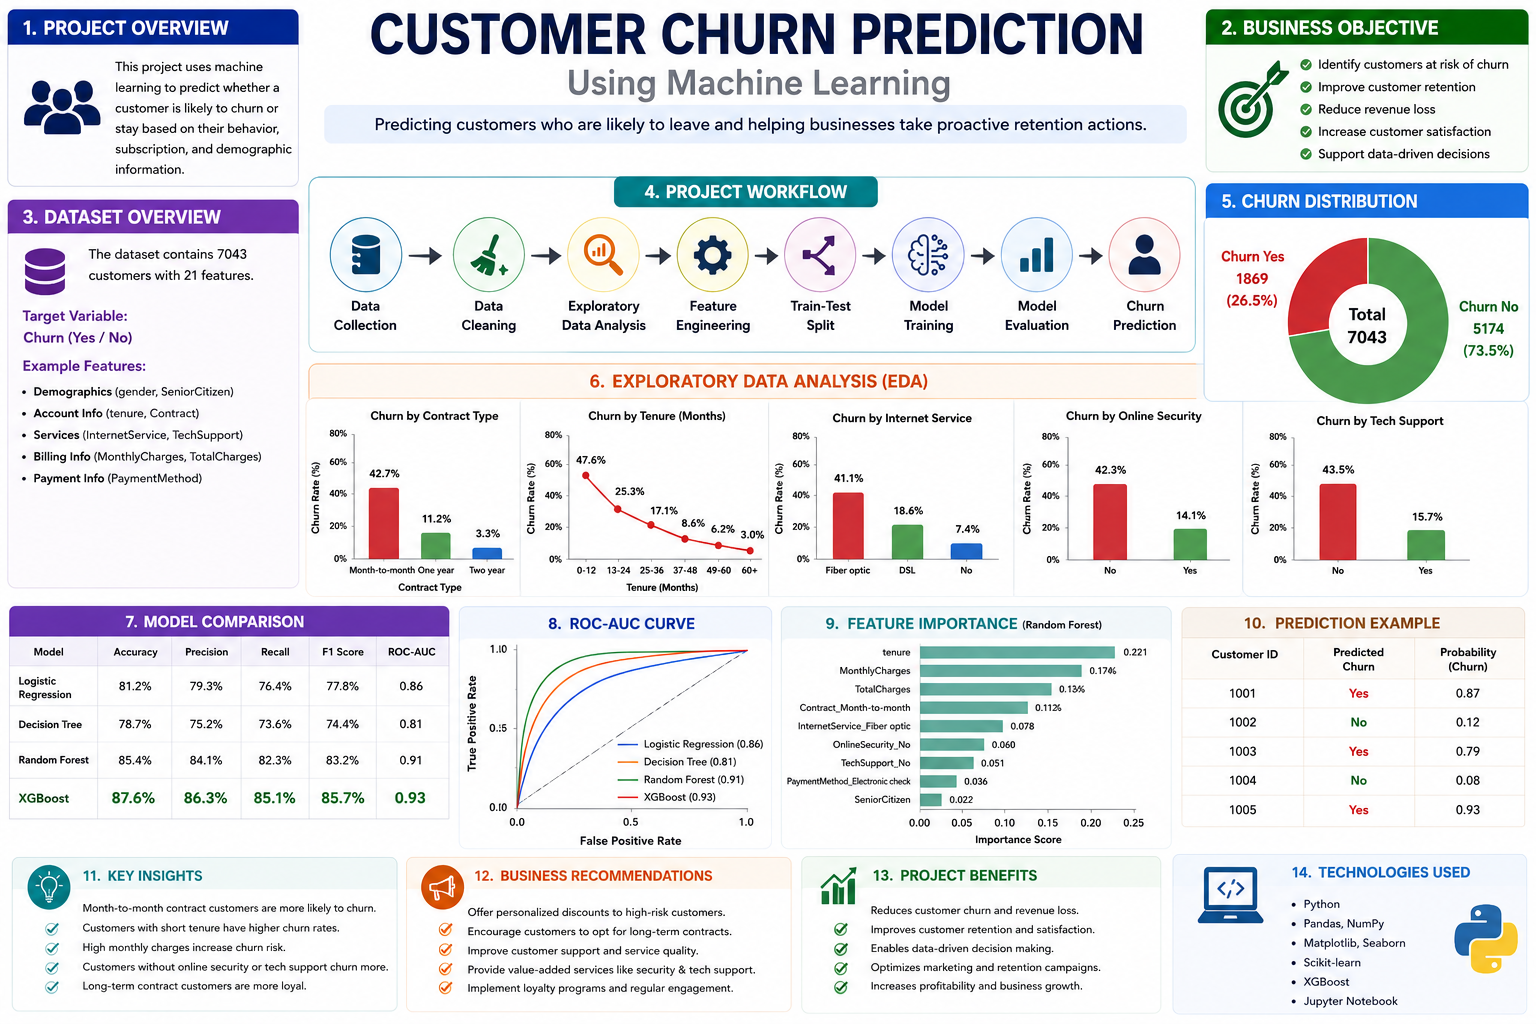

# **Installing and Importing Necessary Libraries**





In [ ]:
# Pandas: Used for data manipulation and analysis.
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

# NumPy: Used for numerical operations and array handling.
import numpy as np

# Matplotlib: Used for creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt

# Seaborn: Built on top of Matplotlib, provides a high-level interface for statistical graphics.
import seaborn as sns

# Scikit-learn (sklearn): A comprehensive library for machine learning tasks, including model tuning, performance evaluation, and data preprocessing.
# improve model accuracy
from sklearn.model_selection import train_test_split, GridSearchCV
# it shows accuracy, prediction, recall, f1 score in single report, it shows correct and wrong predictions in table format, it measures how much model predict correctly, how much predict positive correctly, how much find actual positive cases, prediction and recall balance score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
# bring different values of features into the same range, it convert text values into numbers
from sklearn.preprocessing import StandardScaler, LabelEncoder

# DecisionTreeClassifier: A basic decision tree classifier.
from sklearn.tree import DecisionTreeClassifier

# RandomForestClassifier: An ensemble method that combines multiple decision trees.
from sklearn.ensemble import RandomForestClassifier

# GradientBoostingClassifier: Another ensemble method that builds trees sequentially, correcting the errors of previous trees.
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Loading the Data**

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Gen AI Dataset/Churn Prediction.csv')

# **Data Overview**

In [ ]:
data.shape

(10127, 21)

In [ ]:
data.head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.00,777,11914.00,1.33,1144,42,1.62,0.06
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.00,864,7392.00,1.54,1291,33,3.71,0.10
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.00,0,3418.00,2.59,1887,20,2.33,0.00
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.00,2517,796.00,1.41,1171,20,2.33,0.76
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.00,0,4716.00,2.17,816,28,2.50,0.00
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,1,2,4010.00,1247,2763.00,1.38,1088,24,0.85,0.31
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,1,3,34516.00,2264,32252.00,1.98,1330,31,0.72,0.07
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,2,2,29081.00,1396,27685.00,2.20,1538,36,0.71,0.05
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,2,0,22352.00,2517,19835.00,3.35,1350,24,1.18,0.11
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,3,3,11656.00,1677,9979.00,1.52,1441,32,0.88,0.14


In [ ]:
data.tail(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10117,712503408,Existing Customer,57,M,2,Graduate,Married,$80K - $120K,Blue,40,...,3,4,17925.00,1909,16016.00,0.71,17498,111,0.82,0.11
10118,713755458,Attrited Customer,50,M,1,Unknown,Unknown,$80K - $120K,Blue,36,...,3,4,9959.00,952,9007.00,0.82,10310,63,1.10,0.10
10119,716893683,Attrited Customer,55,F,3,Uneducated,Single,Unknown,Blue,47,...,3,3,14657.00,2517,12140.00,0.17,6009,53,0.51,0.17
10120,710841183,Existing Customer,54,M,1,High School,Single,$60K - $80K,Blue,34,...,2,0,13940.00,2109,11831.00,0.66,15577,114,0.75,0.15
10121,713899383,Existing Customer,56,F,1,Graduate,Single,Less than $40K,Blue,50,...,1,4,3688.00,606,3082.00,0.57,14596,120,0.79,0.16
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.00,1851,2152.00,0.70,15476,117,0.86,0.46
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.00,2186,2091.00,0.80,8764,69,0.68,0.51
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.00,0,5409.00,0.82,10291,60,0.82,0.00
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.00,0,5281.00,0.54,8395,62,0.72,0.00
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,2,4,10388.00,1961,8427.00,0.70,10294,61,0.65,0.19


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [ ]:
data.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,739177606.33,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,36903783.45,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,708082083.00,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,713036770.50,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,717926358.00,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,773143533.00,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,828343083.00,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


- The customers are middle-aged, with an average age of 46 years.
- Most customers have been with the bank for about 3 years.
- Customers generally hold 3–4 banking products.

- On average, customers are inactive for 2 months each year.
-Customers make around 65 transactions per year.
- Credit limits and transaction amounts vary widely among customers.
- The average credit utilization ratio is 27%, showing that most customers use only part of their available credit.
- Customer spending and transaction behavior differ significantly, making these features useful for predicting customer churn.

In [ ]:
# Check for duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# Display the duplicate rows (optional)
# print(duplicate_rows)

Number of duplicate rows: 0


# **Exploratory Data Analysis**

In [ ]:
cat_columns = ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status',
               'Income_Category', 'Card_Category','Total_Relationship_Count', 'Months_Inactive_12_mon',
               'Contacts_Count_12_mon', 'Dependent_count']
num_columns = ['Customer_Age', 'Months_on_book',
               'Credit_Limit', 'Total_Revolving_Bal',
               'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
               'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

### **Univariate Analysis**

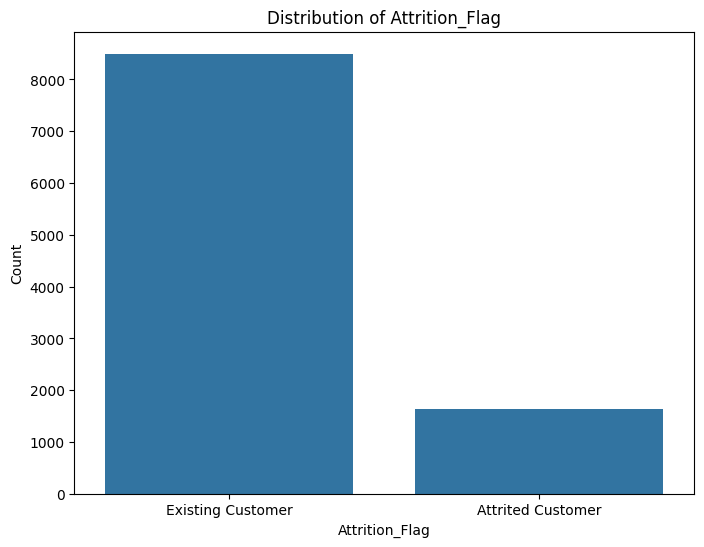

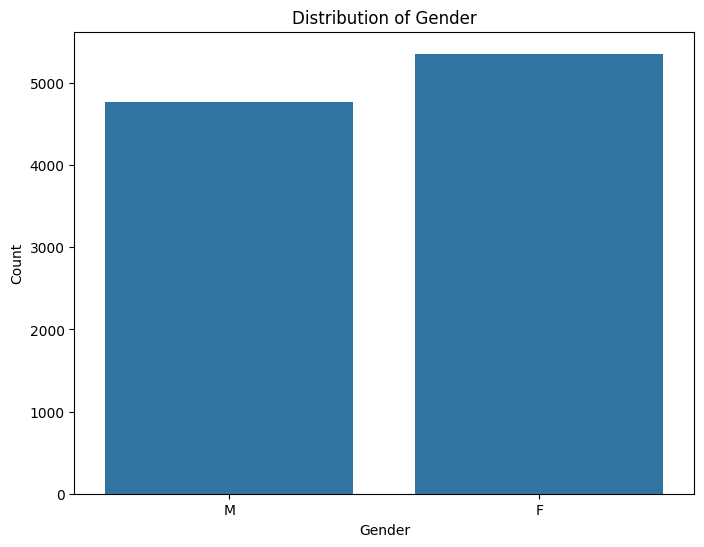

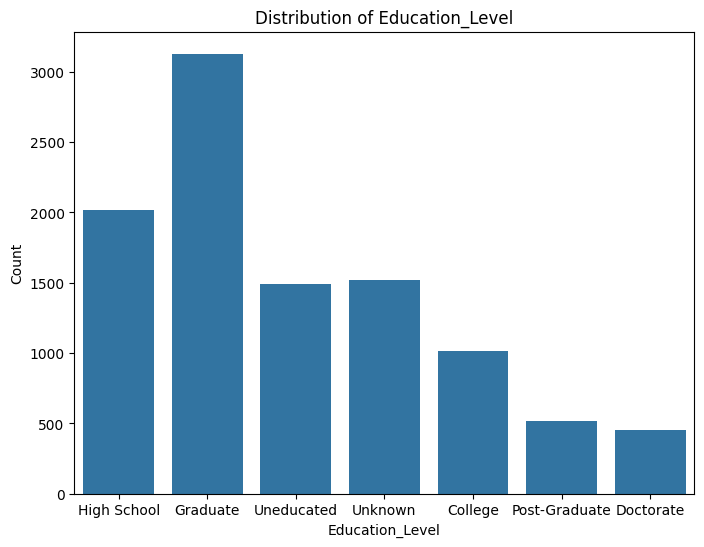

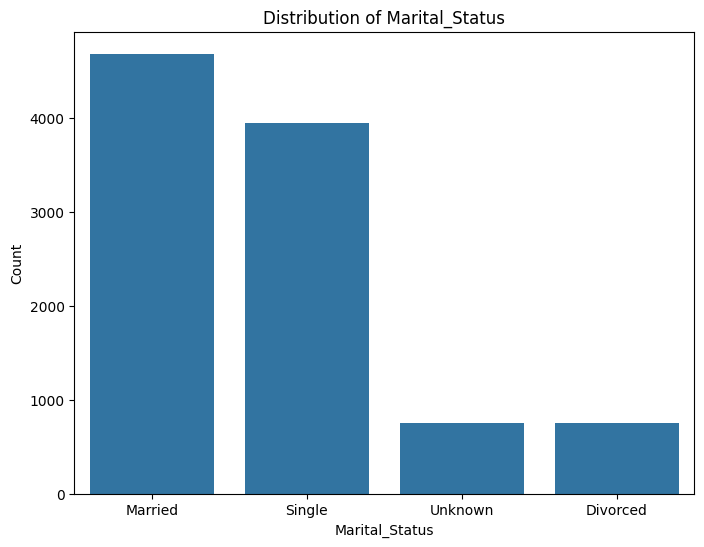

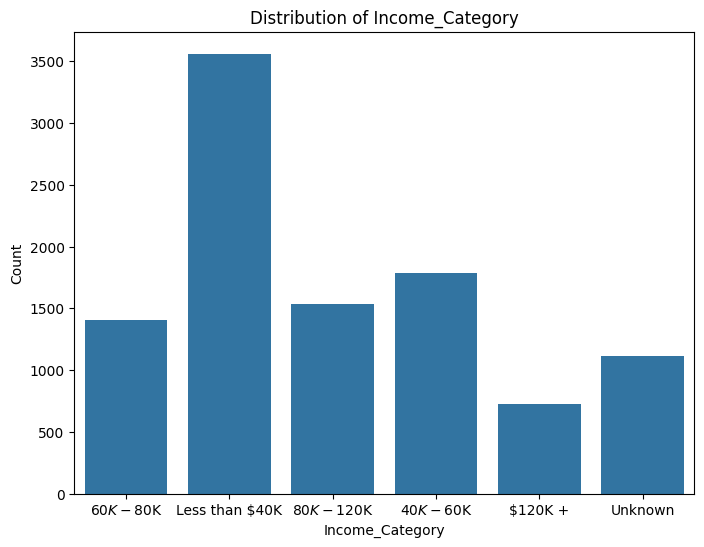

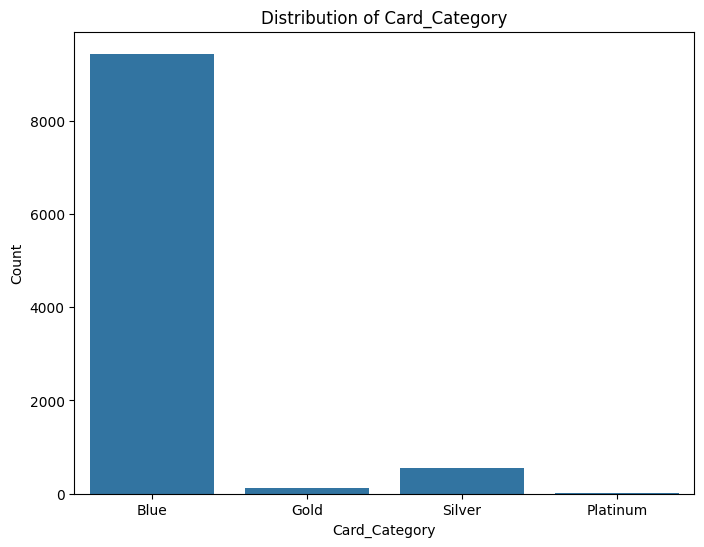

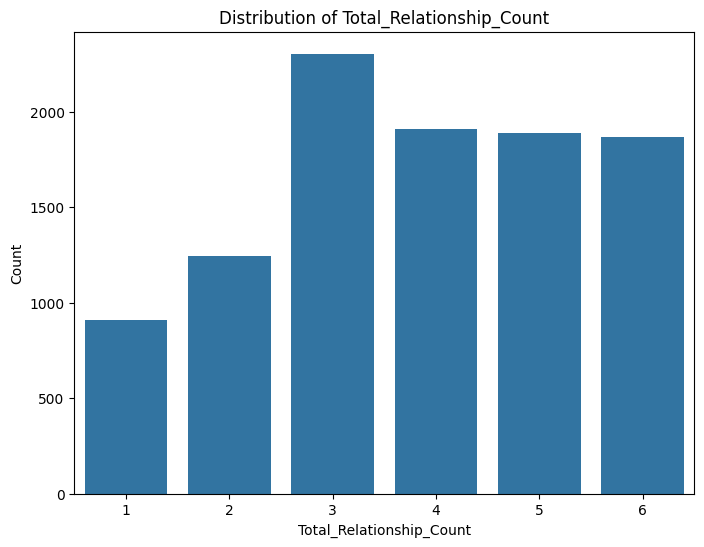

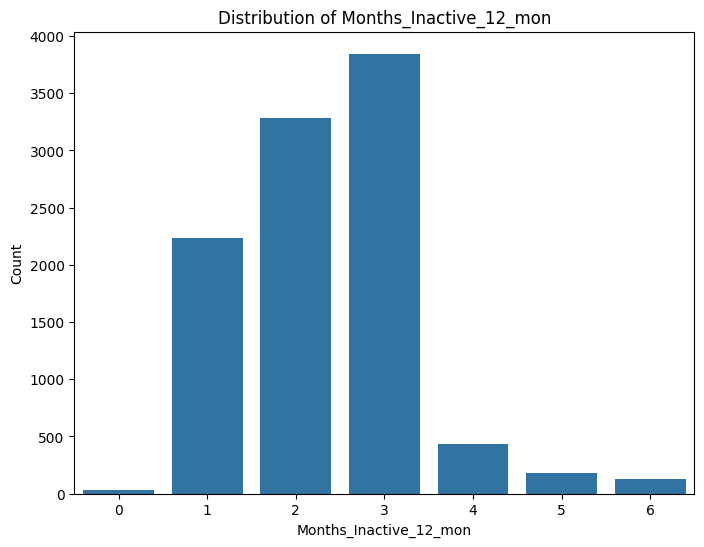

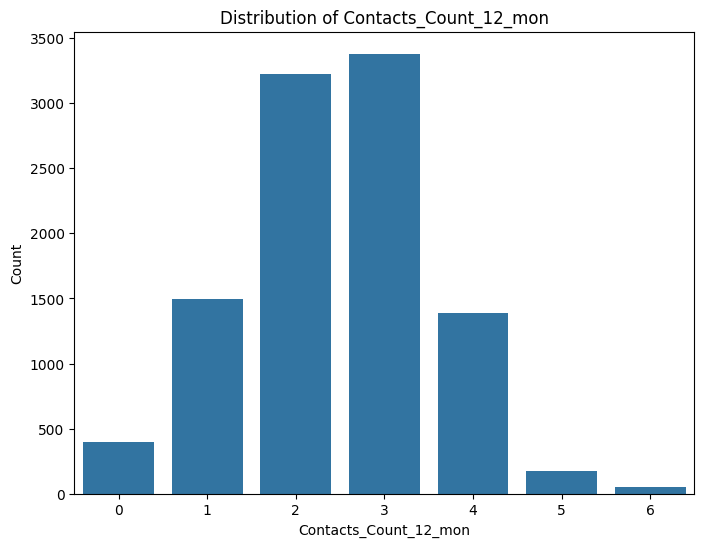

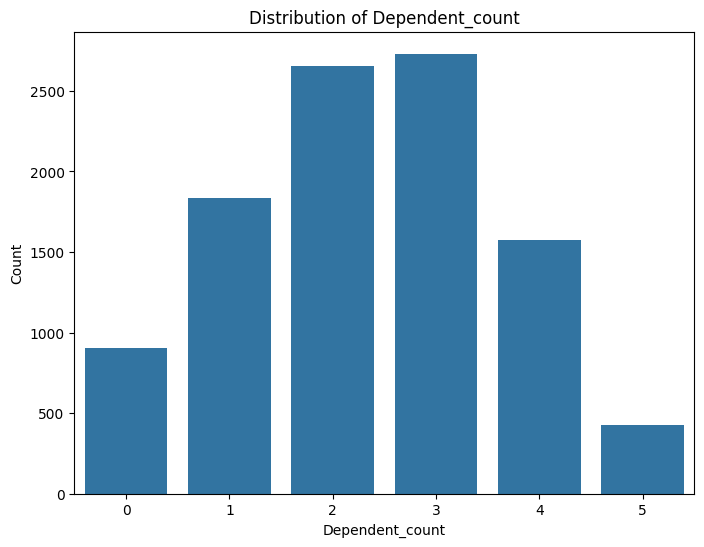

In [ ]:
# Loop through each categorical column
for col in cat_columns:
    plt.figure(figsize=(8, 6))  # Set figure size for better visualization
    sns.countplot(x=col, data=data)  # Create countplot for the current column
    plt.title(f'Distribution of {col}')  # Set title of the plot
    plt.xlabel(col)  # Set x-axis label
    plt.ylabel('Count')  # Set y-axis label
    plt.show()  # Display the plot

#### **Numerical Columns**

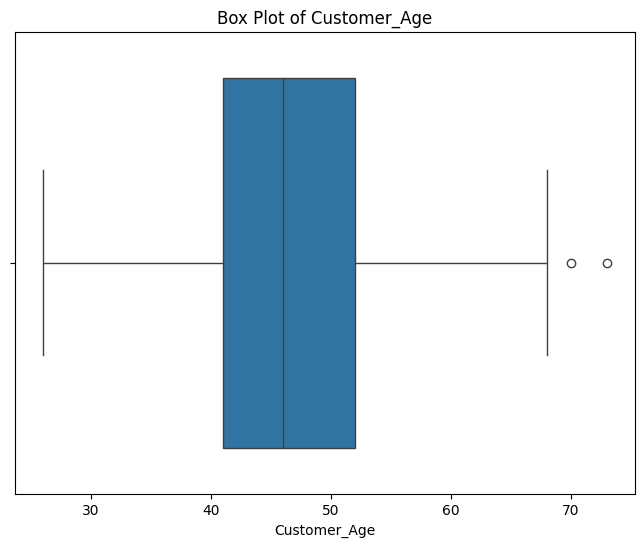

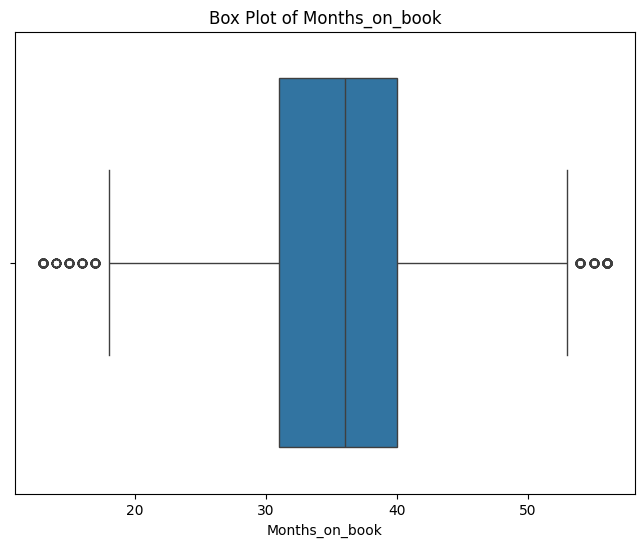

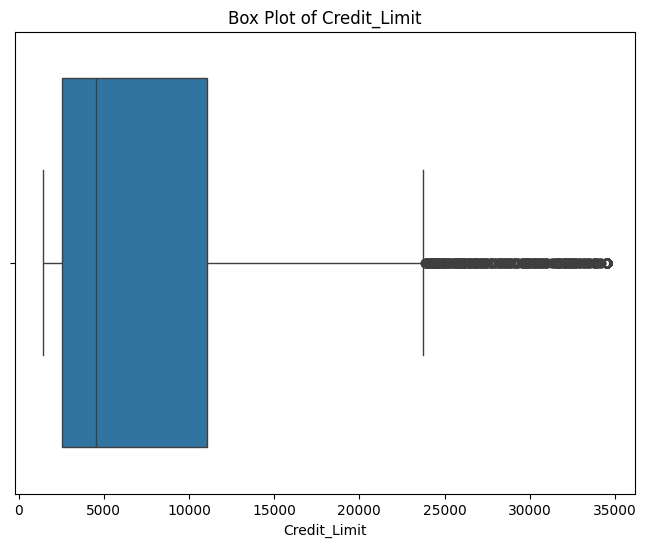

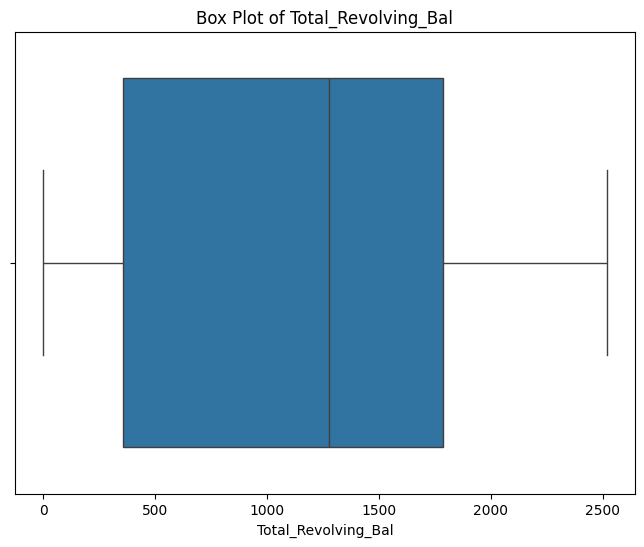

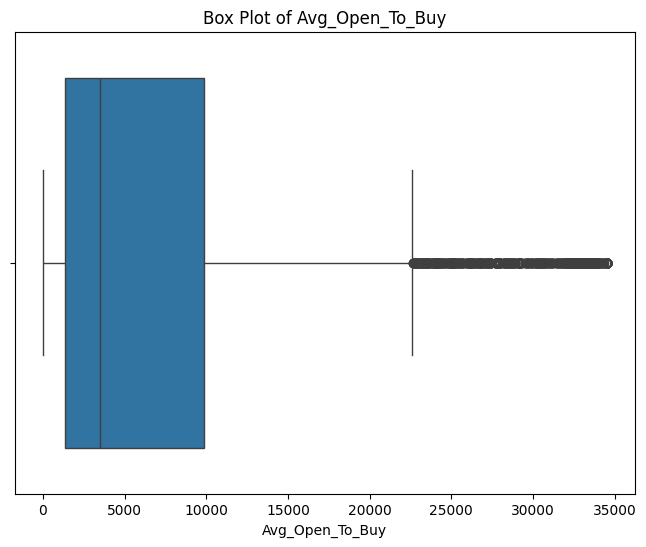

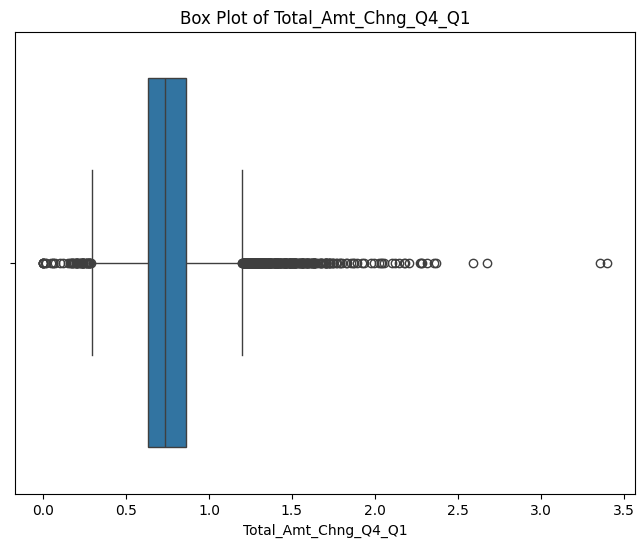

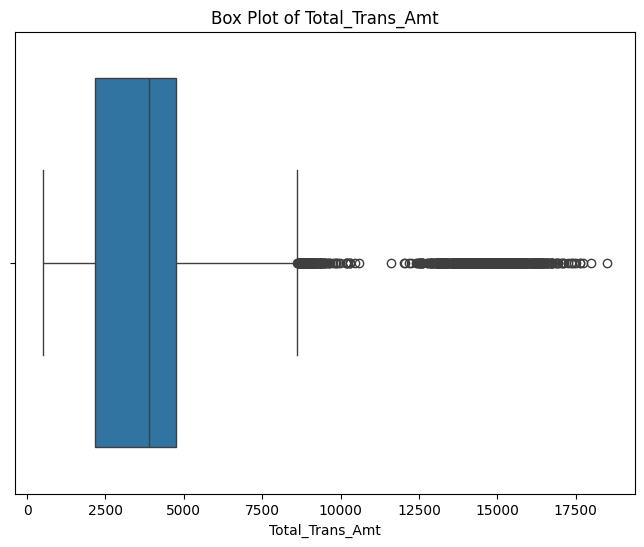

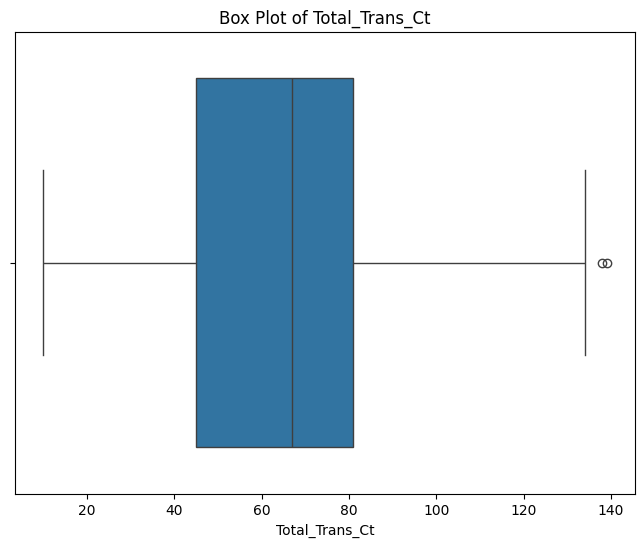

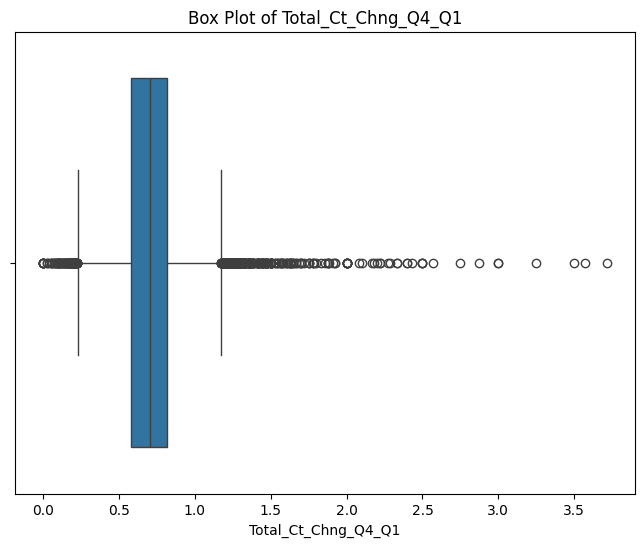

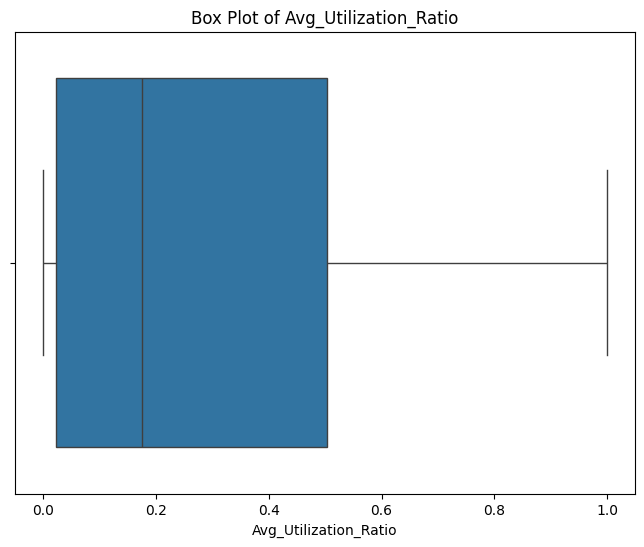

In [ ]:
for column in num_columns:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=data[column])
  plt.title(f'Box Plot of {column}')
  plt.xlabel(column)
  plt.show()

### **Bivariate Analysis**

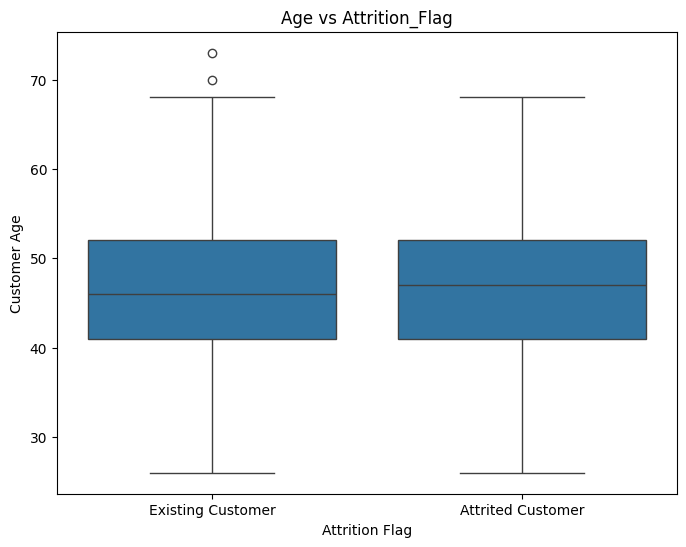

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition_Flag', y='Customer_Age', data=data)
plt.title('Age vs Attrition_Flag')
plt.xlabel('Attrition Flag')
plt.ylabel('Customer Age')
plt.show()

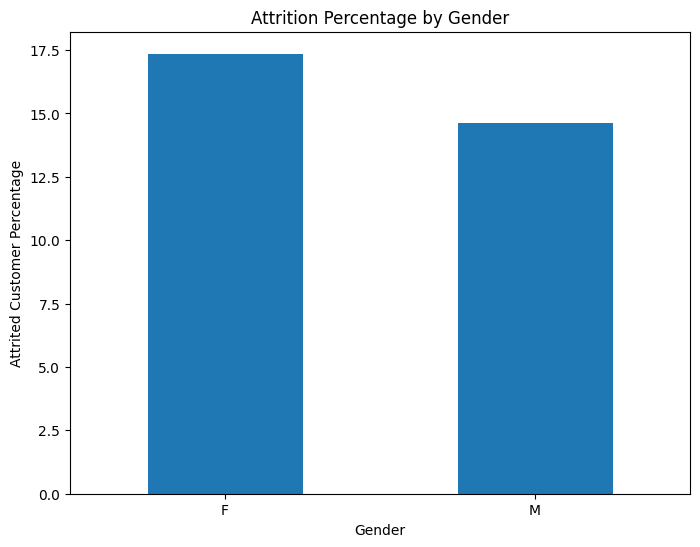

In [ ]:
# Calculate the percentage of attrited customers to existing customers for each gender
gender_attrition = data.groupby('Gender')['Attrition_Flag'].value_counts(normalize=True).unstack()
gender_attrition['Attrited Customer Percentage'] = gender_attrition['Attrited Customer'] * 100
gender_attrition = gender_attrition.sort_values(by='Attrited Customer Percentage', ascending=False)

# Create a bar chart
plt.figure(figsize=(8, 6))
gender_attrition['Attrited Customer Percentage'].plot(kind='bar')
plt.title('Attrition Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrited Customer Percentage')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()

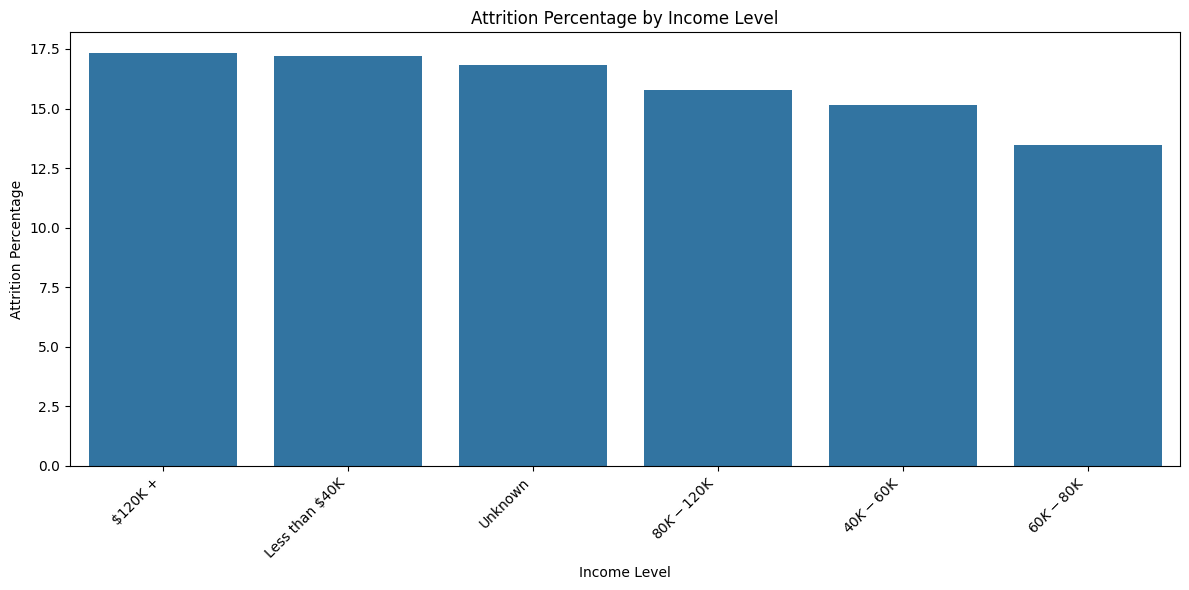

In [ ]:
# Calculate the percentage of attrited customers for each income level
income_churn_counts = data.groupby(['Income_Category', 'Attrition_Flag'])['CLIENTNUM'].count().unstack()
income_churn_percentage = (income_churn_counts['Attrited Customer'] / (income_churn_counts['Attrited Customer'] + income_churn_counts['Existing Customer'])) * 100

# Create a DataFrame for the result and sort by percentage
churn_percentage_df = pd.DataFrame({'Percentage': income_churn_percentage}).sort_values('Percentage', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=churn_percentage_df.index, y='Percentage', data=churn_percentage_df)
plt.title('Attrition Percentage by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

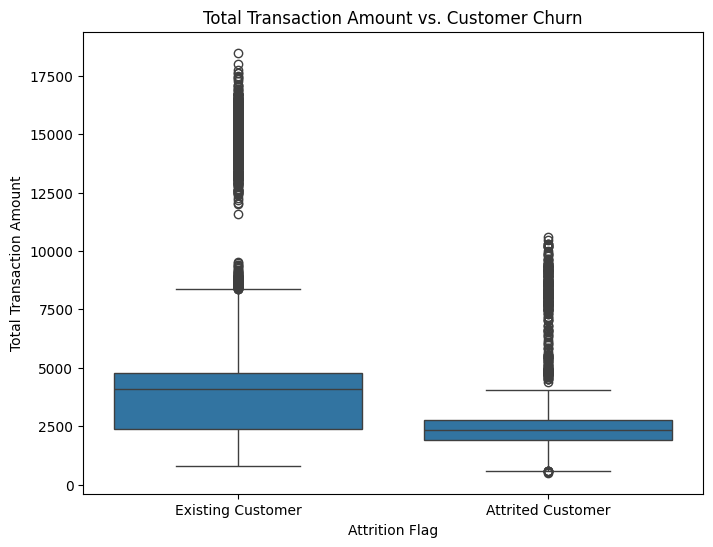

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Amt', data=data)
plt.title('Total Transaction Amount vs. Customer Churn')
plt.xlabel('Attrition Flag')
plt.ylabel('Total Transaction Amount')
plt.show()

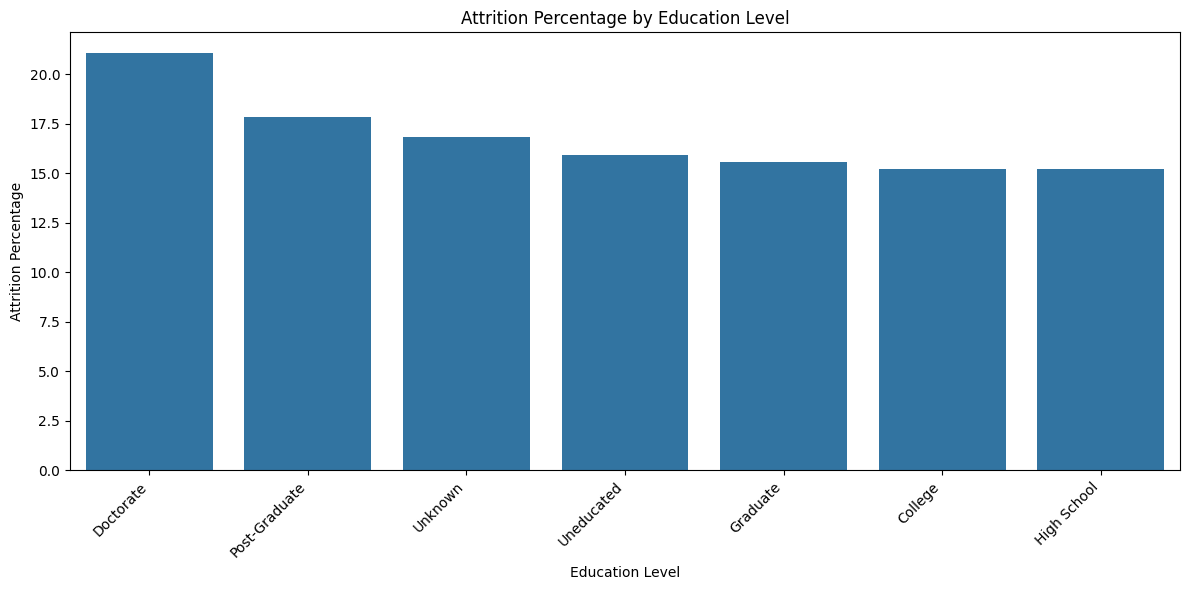

In [ ]:
# Calculate the percentage of attrited customers for each education level
education_churn_counts = data.groupby(['Education_Level', 'Attrition_Flag'])['CLIENTNUM'].count().unstack()
education_churn_percentage = (education_churn_counts['Attrited Customer'] / (education_churn_counts['Attrited Customer'] + education_churn_counts['Existing Customer'])) * 100

# Create a DataFrame for the result and sort by percentage
churn_percentage_df = pd.DataFrame({'Percentage': education_churn_percentage}).sort_values('Percentage', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=churn_percentage_df.index, y='Percentage', data=churn_percentage_df)
plt.title('Attrition Percentage by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

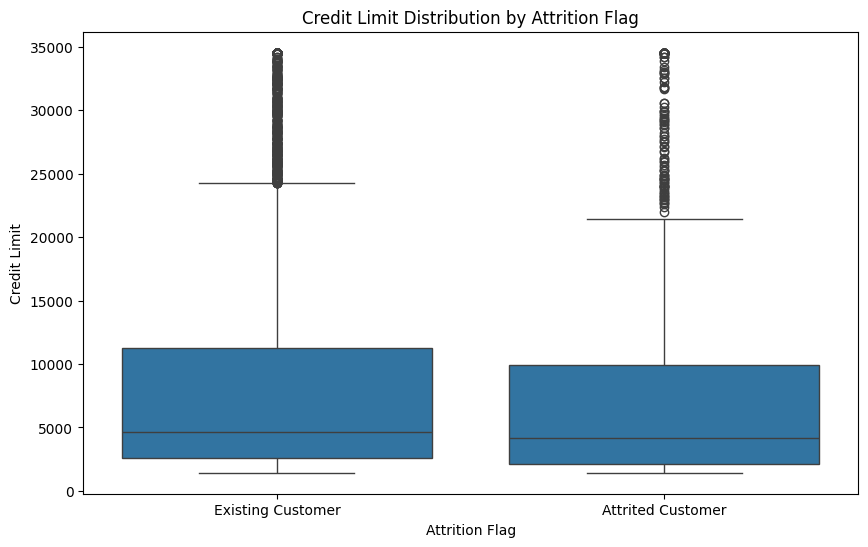

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=data)
plt.title('Credit Limit Distribution by Attrition Flag')
plt.xlabel('Attrition Flag')
plt.ylabel('Credit Limit')
plt.show()

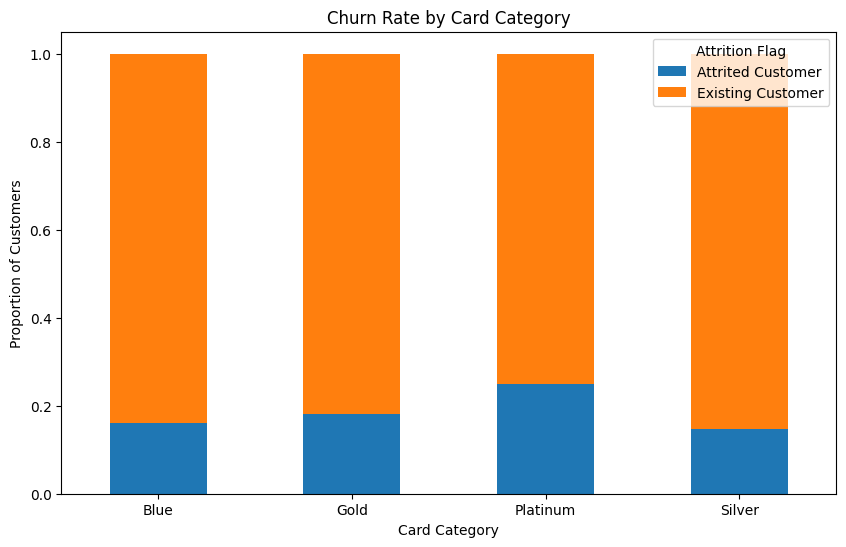

In [ ]:
# Calculate the churn rate for each card category
churn_rates = data.groupby('Card_Category')['Attrition_Flag'].value_counts(normalize=True).unstack()

# Create the stacked bar chart
churn_rates.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Churn Rate by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=0)
plt.legend(title='Attrition Flag')
plt.show()

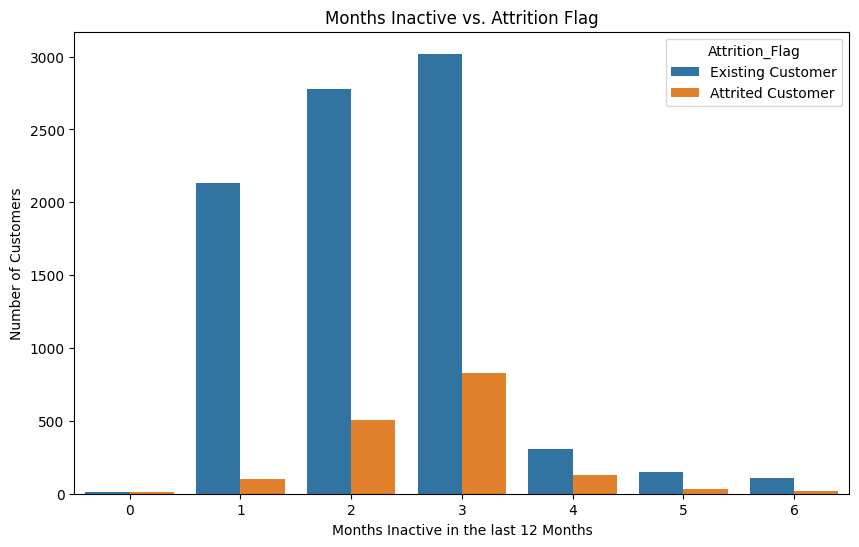

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Months_Inactive_12_mon', hue='Attrition_Flag', data=data)
plt.title('Months Inactive vs. Attrition Flag')
plt.xlabel('Months Inactive in the last 12 Months')
plt.ylabel('Number of Customers')
plt.show()

## **Data Preprocessing**

In [ ]:
data = data.drop('CLIENTNUM', axis=1)

In [ ]:
# Create a mapping for 'Attrition_Flag'
attrition_mapping = {'Existing Customer': 0, 'Attrited Customer': 1}

# Use the map function to encode the column
data['Attrition_Flag'] = data['Attrition_Flag'].map(attrition_mapping)

In [ ]:
# Create a mapping for 'Education_Level' based on hierarchy (example hierarchy)
education_mapping = {
    'Uneducated': 1,
    'High School': 2,
    'College': 3,
    'Graduate': 4,
    'Post-Graduate': 5,
    'Doctorate': 6,
    'Unknown': 0  # Handle 'Unknown' appropriately
}

data['Education_Level'] = data['Education_Level'].map(education_mapping)


# Create a mapping for 'Income_Category' based on hierarchy (example hierarchy)
income_mapping = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 0  # Handle 'Unknown' appropriately
}

data['Income_Category'] = data['Income_Category'].map(income_mapping)

In [ ]:
# Perform n-1 dummy encoding for 'Marital_Status' and 'Card_Category'
data = pd.get_dummies(data, columns=['Marital_Status', 'Card_Category'],
                            drop_first=True, dtype=int)

In [ ]:
# Create a LabelEncoder object
le = LabelEncoder()

# Fit and transform the 'Gender' column
data['Gender'] = le.fit_transform(data['Gender'])

In [ ]:
# Define the target variable (y) and the features (X)
y = data['Attrition_Flag']
X = data.drop('Attrition_Flag', axis=1)

# Split the data into training and testing sets, stratifying by the target variable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7088, 23)
X_test shape: (3039, 23)
y_train shape: (7088,)
y_test shape: (3039,)


## **Model Building**

In [ ]:
model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1',
                                           'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1'])

### **Decision Tree Classifier**

In [ ]:
# Initialize Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on training and testing data
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Evaluate the model on training data
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
train_precision_dt = precision_score(y_train, y_train_pred_dt)
train_recall_dt = recall_score(y_train, y_train_pred_dt)
train_f1_dt = f1_score(y_train, y_train_pred_dt)

# Evaluate the model on testing data
test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
test_precision_dt = precision_score(y_test, y_test_pred_dt)
test_recall_dt = recall_score(y_test, y_test_pred_dt)
test_f1_dt = f1_score(y_test, y_test_pred_dt)

# Store the results in model_eval_results
model_eval_results.loc[len(model_eval_results)] = ['Decision Tree', train_accuracy_dt, train_precision_dt, train_recall_dt, train_f1_dt,
                                                  test_accuracy_dt, test_precision_dt, test_recall_dt, test_f1_dt]

# Show the model evaluation results dataframe
print("\nModel Evaluation Results:")
model_eval_results


Model Evaluation Results:


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.00,1.00,1.00,1.00,0.93,0.78,0.81,0.80


* **Train Performance**: Perfect scores (1.00) across all metrics suggest that the model has memorized the training data.
* **Test Performance**: Accuracy is decent at 0.93, but **precision (0.78)** and **recall (0.81)** drop significantly.
* **Inference**: The model is **overfitting** — it performs very well on training data but generalizes poorly to unseen data.

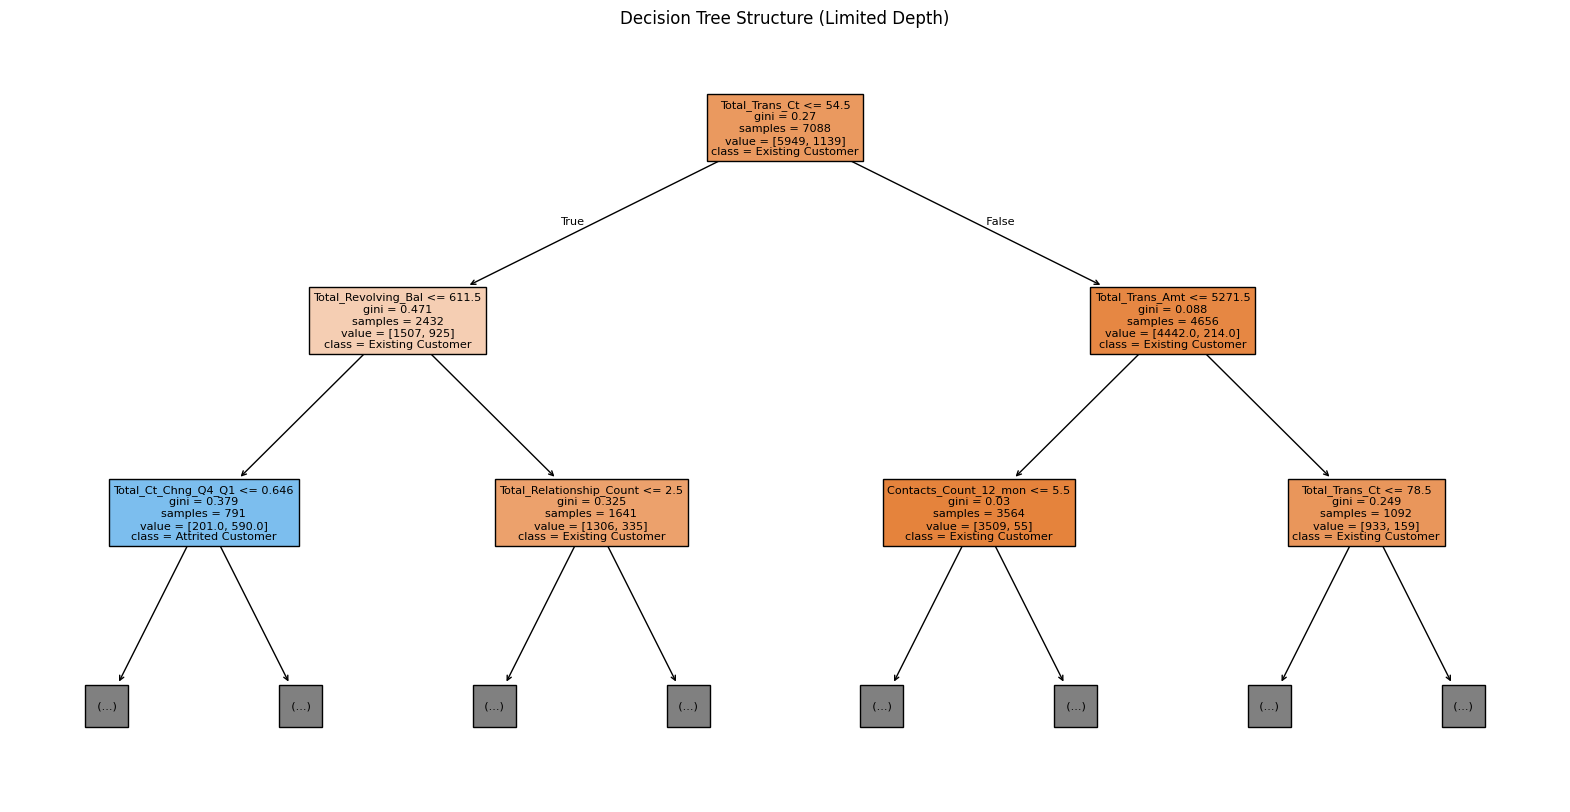

In [ ]:
from sklearn.tree import plot_tree

# Visualize the decision tree (you might need to limit the depth for better readability)
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("Decision Tree Structure (Limited Depth)")
plt.show()

### **Random Forest**

In [ ]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on testing data
y_test_pred_rf = rf_model.predict(X_test)

# Make predictions on training data
y_train_pred_rf = rf_model.predict(X_train)

# Evaluate the model on training data
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_precision_rf = precision_score(y_train, y_train_pred_rf)
train_recall_rf = recall_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf)

# Evaluate the model on testing data
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_precision_rf = precision_score(y_test, y_test_pred_rf)
test_recall_rf = recall_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf)

# Store the results in model_eval_results
model_eval_results.loc[len(model_eval_results)] = ['Random Forest', train_accuracy_rf, train_precision_rf, train_recall_rf, train_f1_rf,
                                                  test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf]

# Show the model evaluation results dataframe
print("\nModel Evaluation Results:")
model_eval_results


Model Evaluation Results:


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.00,1.00,1.00,1.00,0.93,0.78,0.81,0.80
1,Random Forest,1.00,1.00,1.00,1.00,0.96,0.92,0.80,0.85


* **Train Performance**: Also shows perfect scores (1.00), indicating a strong fit to training data.
* **Test Performance**: High accuracy (0.96) and better balance across metrics — precision (0.92), recall (0.80), and F1 (0.85).
* **Inference**: Although slightly overfitting, the model still generalizes **well to test data**, making it more reliable than the Decision Tree.

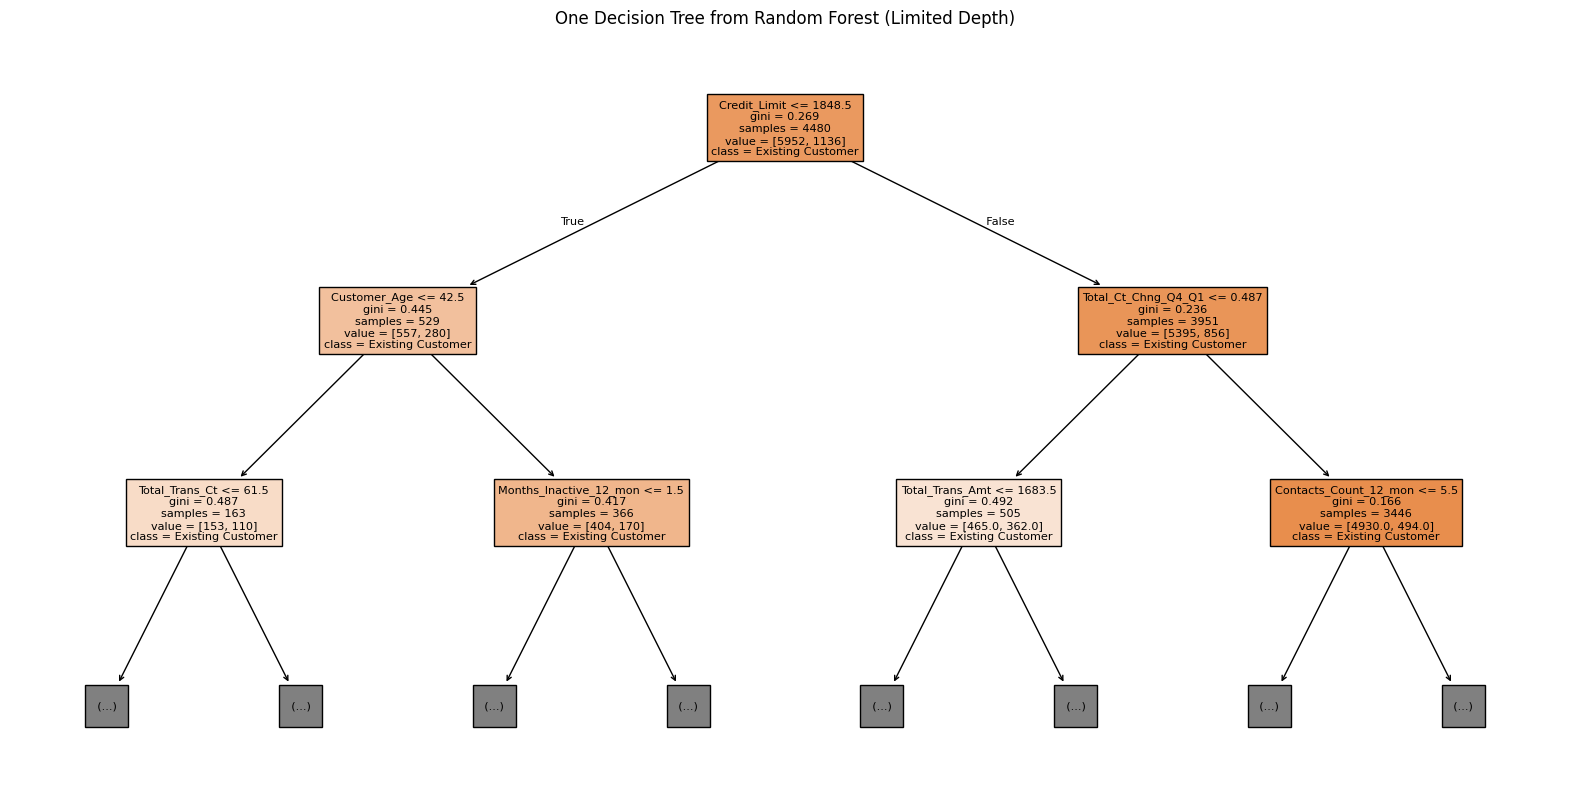

In [ ]:
# You can visualize one of the trees from the Random Forest
plt.figure(figsize=(20,10))
# Select the first tree from the forest
plot_tree(rf_model.estimators_[0], filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("One Decision Tree from Random Forest (Limited Depth)")
plt.show()

### **Gradient Boosting**

In [ ]:
# Initialize Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions on testing data
y_test_pred_gb = gb_model.predict(X_test)

# Make predictions on training data
y_train_pred_gb = gb_model.predict(X_train)

# Evaluate the model on training data
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_precision_gb = precision_score(y_train, y_train_pred_gb)
train_recall_gb = recall_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb)

# Evaluate the model on testing data
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_precision_gb = precision_score(y_test, y_test_pred_gb)
test_recall_gb = recall_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb)

# Store the results in model_eval_results
model_eval_results.loc[len(model_eval_results)] = ['Gradient Boosting', train_accuracy_gb, train_precision_gb, train_recall_gb, train_f1_gb,
                                                  test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb]

# Show the model evaluation results dataframe
print("\nModel Evaluation Results:")
model_eval_results


Model Evaluation Results:


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.00,1.00,1.00,1.00,0.93,0.78,0.81,0.80
1,Random Forest,1.00,1.00,1.00,1.00,0.96,0.92,0.80,0.85
2,Gradient Boosting,0.98,0.96,0.90,0.93,0.96,0.93,0.81,0.86


* **Train Performance**: Slightly below perfect, with accuracy (0.98), precision (0.96), recall (0.90), and F1 (0.93), indicating good learning without severe overfitting.
* **Test Performance**: Strong generalization with **accuracy (0.96)**, precision (0.93), recall (0.81), and F1 (0.86).
* **Inference**: Offers the **best balance between bias and variance** — great performance on both training and test sets with minimal overfitting.

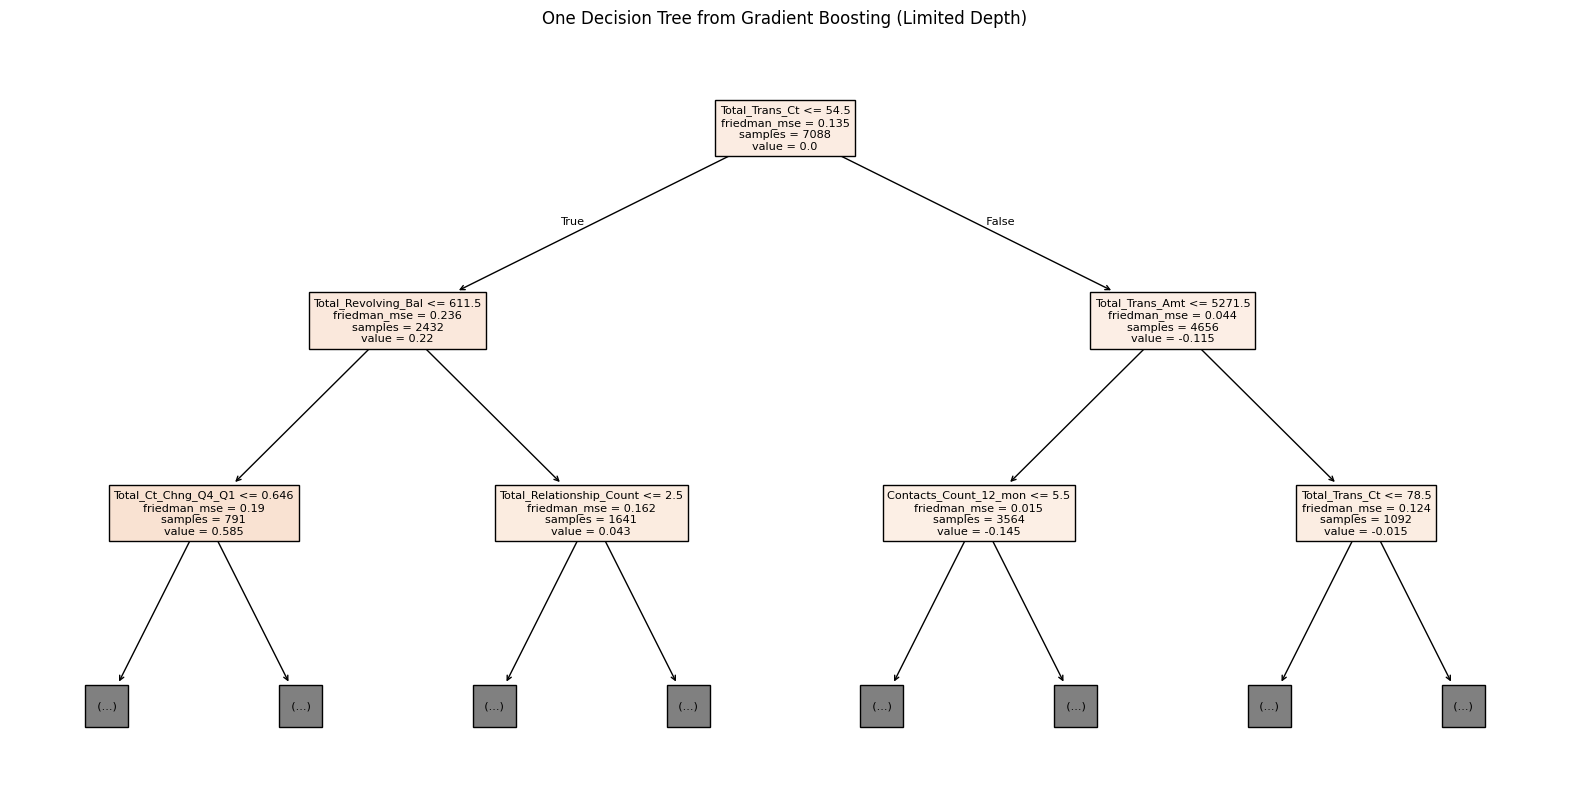

In [ ]:
# Visualize one of the trees from the Gradient Boosting model
plt.figure(figsize=(20,10))
# Select the first tree from the forest (Gradient Boosting stores trees in estimators_)
plot_tree(gb_model.estimators_[0, 0], filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("One Decision Tree from Gradient Boosting (Limited Depth)")
plt.show()

## **Final Model Selection**

### Model Comparison

Among the three models, Gradient Boosting provides the best balance between training and test performance, with high precision, recall, and F1-score on unseen data. While Decision Tree and Random Forest show signs of overfitting, Gradient Boosting generalizes better than them.
**Therefore, Gradient Boosting is selected as the final model.**

### **Feature Importance**

Top 10 Features Impacting Customer Churn:
                     Feature  Importance
14            Total_Trans_Ct        0.33
13           Total_Trans_Amt        0.19
10       Total_Revolving_Bal        0.19
6   Total_Relationship_Count        0.11
15       Total_Ct_Chng_Q4_Q1        0.10
12      Total_Amt_Chng_Q4_Q1        0.03
8      Contacts_Count_12_mon        0.02
0               Customer_Age        0.02
7     Months_Inactive_12_mon        0.01
11           Avg_Open_To_Buy        0.00


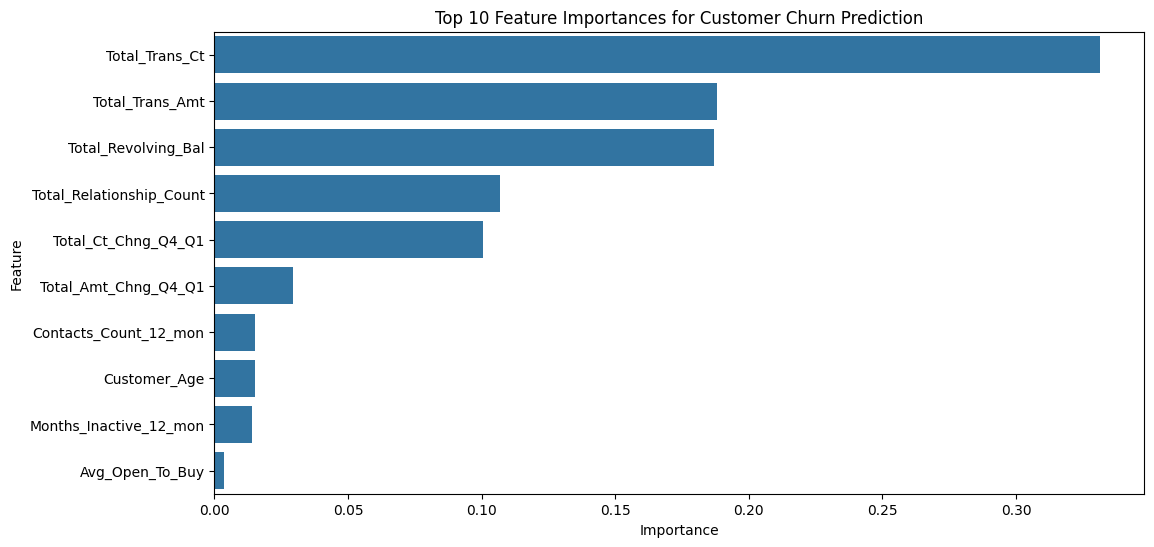

In [ ]:
# Get feature importances from the trained Gradient Boosting model
feature_importances = gb_model.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Print the top 10 features that most significantly impact customer churn
print("Top 10 Features Impacting Customer Churn:")
print(feature_importance_df.head(10))

# You can visualize the feature importances using a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances for Customer Churn Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### **Gradient Boosting - Fine Tuning**

In [ ]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [75, 100 , 125],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.5, 0.6]
}

# Initialize the Gradient Boosting Classifier
gb_model_tuned = GradientBoostingClassifier(random_state=42)

# Perform GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=gb_model_tuned, param_grid=param_grid, scoring='recall', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Train the best model found by GridSearchCV
best_gb_model = grid_search.best_estimator_
best_gb_model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=4, n_estimators=125, random_state=42,
                           subsample=0.5)

**The parameters for the Tuned Gradient Boosting model are:**

* `max_depth = 4`: Restricts the depth of each tree, helping to balance model complexity and overfitting.
* `n_estimators = 125`: Uses 125 boosting rounds (trees) to build a strong ensemble without excessive computation.
* `subsample = 0.5`: Trains each tree on a random 50% subset of the data, introducing regularization and helping to reduce overfitting.
* `random_state = 42`: Ensures reproducibility of results.

In [ ]:
# Make predictions on training and testing data with the fine-tuned model
y_train_pred_tuned = best_gb_model.predict(X_train)
y_test_pred_tuned = best_gb_model.predict(X_test)

# Evaluate the fine-tuned model on training data
train_accuracy_tuned = accuracy_score(y_train, y_train_pred_tuned)
train_precision_tuned = precision_score(y_train, y_train_pred_tuned)
train_recall_tuned = recall_score(y_train, y_train_pred_tuned)
train_f1_tuned = f1_score(y_train, y_train_pred_tuned)

# Evaluate the fine-tuned model on testing data
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)
test_precision_tuned = precision_score(y_test, y_test_pred_tuned)
test_recall_tuned = recall_score(y_test, y_test_pred_tuned)
test_f1_tuned = f1_score(y_test, y_test_pred_tuned)

# Store the results in model_eval_results
model_eval_results.loc[len(model_eval_results)] = ['Gradient Boosting (Tuned)', train_accuracy_tuned, train_precision_tuned, train_recall_tuned, train_f1_tuned,
                                                  test_accuracy_tuned, test_precision_tuned, test_recall_tuned, test_f1_tuned]

# Show the model evaluation results dataframe
print("\nModel Evaluation Results:")
model_eval_results


Model Evaluation Results:


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.00,1.00,1.00,1.00,0.93,0.78,0.81,0.80
1,Random Forest,1.00,1.00,1.00,1.00,0.96,0.92,0.80,0.85
2,Gradient Boosting,0.98,0.96,0.90,0.93,0.96,0.93,0.81,0.86
3,Gradient Boosting (Tuned),0.99,0.98,0.96,0.97,0.96,0.93,0.84,0.88


After fine-tuning the Gradient Boosting model, we observed an improvement in performance metrics, particularly an **increase in recall on the test set** compared to the base model. This means the tuned model is now better at correctly identifying customers who are likely to churn.

### **Predicting with New Data**

To predict with new data, ensure that the new data has the same features and has undergone the same preprocessing steps as the training data. This includes dropping the 'CLIENTNUM', encoding 'Attrition_Flag', 'Education_Level', 'Income_Category', and 'Gender', and performing one-hot encoding for 'Marital_Status' and 'Card_Category'.

In [ ]:
import pandas as pd
new_data_raw = pd.DataFrame({
    'CLIENTNUM': [700000000],
    'Customer_Age': [40],
    'Gender': ['M'],
    'Dependent_count': [2],
    'Education_Level': ['Graduate'],
    'Marital_Status': ['Married'],
    'Income_Category': ['$60K - $80K'],
    'Card_Category': ['Blue'],
    'Months_on_book': [30],
    'Total_Relationship_Count': [4],
    'Months_Inactive_12_mon': [1],
    'Contacts_Count_12_mon': [2],
    'Credit_Limit': [10000.00],
    'Total_Revolving_Bal': [1200],
    'Avg_Open_To_Buy': [8800.00],
    'Total_Amt_Chng_Q4_Q1': [1.0],
    'Total_Trans_Amt': [3000],
    'Total_Trans_Ct': [50],
    'Total_Ct_Chng_Q4_Q1': [1.0],
    'Avg_Utilization_Ratio': [0.12]
})
new_data = new_data_raw.drop('CLIENTNUM', axis=1)
new_data['Education_Level'] = new_data['Education_Level'].map(education_mapping)
new_data['Income_Category'] = new_data['Income_Category'].map(income_mapping)
new_data['Gender'] = le.transform(new_data['Gender'])
new_data_processed_ohe = pd.get_dummies(new_data, columns=['Marital_Status', 'Card_Category'], drop_first=True, dtype=int)
new_data = new_data_processed_ohe.reindex(columns=X_train.columns, fill_value=0)

display(new_data)

,Customer_Age,Gender,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,40,1,2,4,3,30,4,1,2,10000.00,...,3000,50,1.00,0.12,0,0,0,0,0,0


In [ ]:
# Predict using the best_gb_model
prediction = best_gb_model.predict(new_data)

# Interpret and display only the prediction
predicted_class = 'Attrited Customer' if prediction[0] == 1 else 'Existing Customer'
print(f"Predicted Class for new data: {predicted_class}")

Predicted Class for new data: Existing Customer


# **Conclusion**

*   Based on the input provided, the fine-tuned Gradient Boosting model predicts that this customer is an Existing Customer.


